# 02 — Baseline Model

## Business case

Recap from 01_eda.ipynb: the target marks whether a client is labelled as electricity/gas fraud. The operational goal is a ranked shortlist for a capacity-limited inspection team, so PR-AUC (average precision) is the primary metric, with ROC-AUC reported as a secondary ranking check.

## What this notebook does

It compares a DummyClassifier reference against logistic regression. We use logistic regression rather than literal linear regression because the target is a 0/1 label, not a continuous quantity.

This notebook loads the complete df_training.csv created by 01_eda.ipynb. It contains client_id, target, and the 15 baseline inputs selected in the EDA.

Because there is no separate labelled test file, this notebook uses five-fold stratified cross-validation. Each validation fold is scored by a pipeline fitted on the other folds, so preprocessing and model fitting stay inside the fold. The out-of-fold predictions are used for the precision-recall curve and inspection-capacity analysis.

## Imports and constants

In [129]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
TRAINING_FEATURES_PATH = PROCESSED_DIR / "df_training.csv"

RSEED = 42
N_SPLITS = 5

if not TRAINING_FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Missing {TRAINING_FEATURES_PATH}. Run 01_eda.ipynb with "
        "SAVE_TRAINING_ARTIFACTS=true first."
    )

## Step 1 — Load the complete client-level training data

The EDA already created one row per client and selected the 15 baseline inputs. This notebook does not recreate invoice features and does not expect a separate labelled test file.

In [130]:
df_training = pd.read_csv(TRAINING_FEATURES_PATH)
df_training["client_id"] = df_training["client_id"].astype("string")
df_training["target"] = df_training["target"].astype("int8")

expected_columns = {
    "client_id", "target",
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
    "client_catg", "disrict", "region",
}
missing_columns = sorted(expected_columns - set(df_training.columns))
if missing_columns:
    raise ValueError(
        f"{TRAINING_FEATURES_PATH} is missing required baseline columns: {missing_columns}"
    )

overview = pd.DataFrame({
    "rows": [len(df_training)],
    "unique_clients": [df_training["client_id"].nunique()],
    "fraud_rate": [df_training["target"].mean()],
})
display(overview)
display(df_training.head())

,rows,unique_clients,fraud_rate
0,135493,135493,0.055841


,client_id,target,invoice_count,active_days,mean_consumption,zero_consumption_rate,elec_share,mean_invoice_gap_days,backwards_index_rate,meter_count,mean_monthly_submission_index_delta,backward_submission_rate,large_mismatch_count,reconciliation_gap_abs_mean,client_catg,disrict,region
0,train_Client_0,0,35,4901,362.971429,0.0,1.0,144.147059,0.0,1,96.961964,0.029412,0,0.0,11,60,101
1,train_Client_1,0,37,4913,557.540541,0.0,1.0,136.472222,0.0,1,274.673613,0.222222,0,0.0,11,69,107
2,train_Client_10,0,18,4921,836.500000,0.0,1.0,289.470588,0.0,1,63.303694,0.058824,0,0.0,11,62,301
3,train_Client_100,0,20,2664,1.200000,0.8,1.0,140.210526,0.0,1,0.300877,0.000000,0,0.0,11,69,105
4,train_Client_1000,0,14,1585,922.642857,0.0,1.0,121.923077,0.0,1,1776.414374,0.230769,0,0.0,11,62,303


## Step 2 — Preprocessing

The business-logic feature decisions already happened in 01_eda.ipynb.

- Excluded from the feature matrix: client_id is a join key and target is the value to predict.
- Numeric columns: median-impute, then standard-scale. Two derived transition features are missing when a client has no usable positive-day meter transition. The imputer learns separately inside each cross-validation training fold.
- Categorical columns: one-hot encode client_catg, disrict, and region, with handle_unknown='ignore' so a category first seen in a later dataset does not crash the model.
- Preprocessing stays inside the model pipeline and is fitted separately for every cross-validation training fold.

Raw dates, tenure, months_number features, and investigation-related fields are not present because the EDA excluded them from the 15-input baseline.

In [131]:
numeric_features = [
    "invoice_count",
    "active_days",
    "mean_consumption",
    "zero_consumption_rate",
    "elec_share",
    "mean_invoice_gap_days",
    "backwards_index_rate",
    "meter_count",
    "mean_monthly_submission_index_delta",
    "backward_submission_rate",
    "large_mismatch_count",
    "reconciliation_gap_abs_mean",
]
categorical_features = ["client_catg", "disrict", "region"]
model_features = numeric_features + categorical_features

X = df_training[model_features]
y = df_training["target"]

print(f"{len(numeric_features)} numeric features, {len(categorical_features)} categorical features")
print(f"Clients used for five-fold cross-validation: {len(X):,}")

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

12 numeric features, 3 categorical features
Clients used for five-fold cross-validation: 135,493


## Step 3 — Dummy baseline vs. logistic regression

class_weight="balanced" gives the smaller fraud class more influence in logistic regression. It is a simple first response to the roughly 5.6% fraud rate.

Both models use the same five-fold StratifiedKFold. Every validation fold is predicted by a pipeline that did not fit on those clients. We report average precision (PR-AUC) as the primary metric and ROC-AUC as a secondary ranking metric.

In [132]:
dummy_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="stratified", random_state=RSEED)),
])
logreg_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RSEED)),
])

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RSEED)

comparison_rows = {}
for name, pipeline in [("dummy", dummy_pipeline), ("logistic_regression", logreg_pipeline)]:
    cv_results = cross_validate(
        pipeline, X, y, cv=cv, scoring=["average_precision", "roc_auc"]
    )
    comparison_rows[name] = {
        "average_precision_mean": cv_results["test_average_precision"].mean(),
        "average_precision_std": cv_results["test_average_precision"].std(),
        "roc_auc_mean": cv_results["test_roc_auc"].mean(),
        "roc_auc_std": cv_results["test_roc_auc"].std(),
    }

cv_model_comparison = pd.DataFrame(comparison_rows).T
print("Five-fold cross-validation results on df_training:")
display(cv_model_comparison)

base_rate = y.mean()
print(f"Fraud rate in df_training: {base_rate:.4f}")


Five-fold cross-validation results on df_training:


,average_precision_mean,average_precision_std,roc_auc_mean,roc_auc_std
dummy,0.056048,0.000345,0.501520,0.003334
logistic_regression,0.169902,0.002292,0.794878,0.002506


Fraud rate in df_training: 0.0558


## Step 4 — Precision-recall curve (out-of-fold)

Out-of-fold logistic-regression scores from `df_training` — every client scored by a fold that did not train on it — let us plot the precision-recall curve directly. The horizontal line shows the fraud rate expected from an uninformative ranking.

In [133]:
oof_proba = cross_val_predict(logreg_pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
y_values = y.to_numpy()

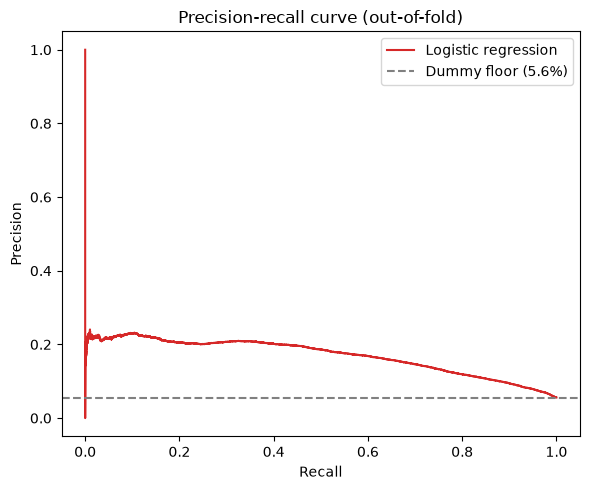

In [134]:
precisions, recalls, _ = precision_recall_curve(y_values, oof_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recalls, precisions, label="Logistic regression", color="#D62828")
ax.axhline(base_rate, linestyle="--", color="grey", label=f"Dummy floor ({base_rate:.1%})")
ax.set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve (out-of-fold)")
ax.legend()
plt.tight_layout()
plt.show()

## Results


- Rerun the five-fold cross-validation cells after generating the new df_training.csv; the previous numbers were produced on the removed split files and are no longer presented as current results.
These are cross-validation results on the labelled training table. They are useful for the first model comparison, but they are not a final untouched test estimate.

Accuracy is not the headline result. With about 5.6% fraud, predicting not fraud for everyone would be highly accurate but would find no fraud.

### Next steps

- Use the out-of-fold predictions for initial false-positive and false-negative error analysis.
- Check performance by client_catg, disrict, region, and invoice-history length.
- Consider a more complex model only after understanding where logistic regression fails.
- When future unlabelled data arrives, run the saved complete feature pipeline and apply the fitted model without refitting.